# 04: Advanced Prediction: Damage Tier & Fatality Tier Classification

Notebook 03 asked a binary question: *will this storm kill someone?* The answer was limited by a 0.60% positive rate and features that didn't capture storm physics.

This notebook adds two things that were missing:
1. **Storm intensity features** - magnitude, tornado F-scale, hurricane category (already in NOAA, exposed in dbt)
2. **Population density** - Census 2020 county-level exposure (new ingestion pipeline)

And asks a richer question: not just *fatal or not*, but **how bad** across both human and economic dimensions.

## Why This Notebook Exists

Notebook 03 asked: *will this storm kill someone?* PR-AUC 0.174 was the ceiling with event type, region, and lag features only. Two things were missing:

**Storm physics.** An EF5 tornado and an EF0 tornado looked identical to the model. NOAA records magnitude and F-scale in the raw data — we exposed them through dbt and added them here.

**Exposure.** A storm hitting 10,000 people vs 1,000,000 people has different outcomes even if the storm is identical. We ingested Census 2020 county population density via a new ingestion pipeline.

---

## What the Pipeline Does

Per 10,000 storm events entering the system:
10,000 events

│

▼ 

Stage 1: NONE vs ANY_DEATH (PR-AUC 0.154)
88 flagged for review ← 99.1% discarded, analyst not paged

│

▼

Stage 2: MINOR vs CRITICAL (PR-AUC 0.061)
12 CRITICAL alerts prioritised ← multi-fatality events (3+ deaths)
76 MINOR events reviewed second


Without this pipeline: all 10,000 events require manual review.
With it: analyst reviews 88 events, 12 CRITICAL alerts surfaced first.

**Stage 1 recall = 38%** — catches more than 1 in 3 fatal events while flagging under 1% of all events.
**Stage 2 CRITICAL recall = 54%** — catches more than half of multi-fatality events among Stage 1 positives.

---

## Key Modelling Decisions

**Hierarchical design over 4-class:** MASS has only 148 events across 30 years — too rare for supervised learning. Decomposing into two binary problems gives each stage a tractable class balance.

**NaN magnitude ≠ zero magnitude:** Events without a recorded magnitude (heat waves, droughts, floods) had NaN filled with 0 in an earlier iteration — this told the model a heat wave had zero wind speed. `HistGradientBoostingClassifier` handles NaN natively via separate decision paths, which improved Stage 1 PR-AUC from 0.138 to 0.154.

**SERIOUS + MASS → CRITICAL:** Emergency management distinguishes single-fatality events from those requiring coordinated multi-agency response (3+ deaths). The merged tier is operationally meaningful and tractable to learn.

**Domain-aware sample weights (Stage 1):** Fatal events from high-danger event types (MARINE, HEAT) are upweighted up to 5× during training, encoding the known fatality rate differences from EDA.
"""



In [5]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from google.cloud import bigquery
from google.oauth2 import service_account

KEYFILE         = r'C:\Users\sansk\Documents\Spring-26\gcp_secret_service\damagereport-499916-f3d6c433577c.json'
PROJECT         = 'damagereport-499916'
STAGING_DATASET = 'dbt_staging'   # views: stg_*, int_*
MARTS_DATASET   = 'dbt_marts'     # tables: mart_*

creds  = service_account.Credentials.from_service_account_file(KEYFILE)
client = bigquery.Client(project=PROJECT, credentials=creds)
print('Connected to BigQuery')

Connected to BigQuery


In [47]:
query = """
SELECT
    e.event_id,
    e.event_year,
    e.event_month,
    e.event_type_group,
    e.region,
    e.state,
    e.county_zone_name,
    e.decade,

    -- Storm intensity
    e.tornado_f_scale,
    e.magnitude,
    e.magnitude_type,
    e.hurricane_category,

    -- Exposure
    e.population_density,

    -- Human impact (target 1 basis)
    COALESCE(e.deaths_direct, 0) AS total_deaths,

    -- Economic impact (target 2 basis)
    e.total_damage_2024_usd

FROM `damagereport-499916.dbt_staging.int_events_enriched` e
WHERE e.event_year BETWEEN 1996 AND 2025
  AND e.is_pre_standardization = FALSE
"""

df_raw = client.query(query).to_dataframe()
print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nMissing population_density: {df_raw['population_density'].isna().mean():.1%}")
print(f"Missing magnitude:           {df_raw['magnitude'].isna().mean():.1%}")
print(f"Missing hurricane_category:  {df_raw['hurricane_category'].isna().mean():.1%}")
print(f"Missing tornado_f_scale:     {df_raw['tornado_f_scale'].isna().mean():.1%}")

Rows: 1,786,831
Columns: ['event_id', 'event_year', 'event_month', 'event_type_group', 'region', 'state', 'county_zone_name', 'decade', 'tornado_f_scale', 'magnitude', 'magnitude_type', 'hurricane_category', 'population_density', 'total_deaths', 'total_damage_2024_usd']

Missing population_density: 17.5%
Missing magnitude:           48.5%
Missing hurricane_category:  100.0%
Missing tornado_f_scale:     97.6%


In [64]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1786831 entries, 0 to 1786830
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   event_id               str    
 1   event_year             Int64  
 2   event_month            str    
 3   event_type_group       str    
 4   region                 str    
 5   state                  str    
 6   county_zone_name       str    
 7   decade                 Int64  
 8   tornado_f_scale        str    
 9   magnitude              float64
 10  magnitude_type         str    
 11  hurricane_category     float64
 12  population_density     float64
 13  total_deaths           Int64  
 14  total_damage_2024_usd  float64
dtypes: Int64(3), float64(4), str(8)
memory usage: 292.8 MB


In [62]:
# Tier definitions (domain-based)
def assign_damage_tier(val):
    if pd.isna(val) or val == 0:   return 'LOW'
    if val < 10_000:               return 'LOW'
    if val < 1_000_000:            return 'MEDIUM'
    if val < 100_000_000:          return 'HIGH'
    return 'CATASTROPHIC'

def assign_fatality_tier(val):
    if val == 0:    return 'NONE'
    if val <= 2:    return 'MINOR'
    if val <= 10:   return 'SERIOUS'
    return 'MASS'

df = df_raw.copy()
df['damage_tier']   = df['total_damage_2024_usd'].apply(assign_damage_tier)
df['fatality_tier'] = df['total_deaths'].apply(assign_fatality_tier)

tier_order_dmg = ['LOW', 'MEDIUM', 'HIGH', 'CATASTROPHIC']
tier_order_fat = ['NONE', 'MINOR', 'SERIOUS', 'MASS']

print("Damage Tier Distribution")
dmg_counts = df['damage_tier'].value_counts().reindex(tier_order_dmg)
for tier, cnt in dmg_counts.items():
    print(f"  {tier:<15} {cnt:>8,}  ({cnt/len(df):.1%})")

print("\nFatality Tier Distribution")
fat_counts = df['fatality_tier'].value_counts().reindex(tier_order_fat)
for tier, cnt in fat_counts.items():
    print(f"  {tier:<15} {cnt:>8,}  ({cnt/len(df):.1%})")

Damage Tier Distribution
  LOW             1,570,879  (87.9%)
  MEDIUM           194,799  (10.9%)
  HIGH              20,184  (1.1%)
  CATASTROPHIC         969  (0.1%)

Fatality Tier Distribution
  NONE            1,775,978  (99.4%)
  MINOR              9,811  (0.5%)
  SERIOUS              894  (0.1%)
  MASS                 148  (0.0%)


In [63]:
# Feature engineering 

# 1. Tornado F-scale: EF0-EF5, F0-F5 → 0-5 integer; missing → -1 (not a tornado)
def encode_fscale(val):
    if pd.isna(val): return -1
    v = str(val).upper().replace('EF','').replace('F','').strip()
    try:    return int(v)
    except: return -1

df['fscale_num'] = df['tornado_f_scale'].apply(encode_fscale)

# 2. Magnitude: 0 where missing (no recorded physical intensity)
# df['magnitude'] = df['magnitude'].fillna(0)

# 3. Population density: fill with dataset median (marine/offshore events)
pop_median = df['population_density'].median()
df['population_density'] = df['population_density'].fillna(pop_median)

# 4. Month -  numeric
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df['month_num'] = df['event_month'].map(month_map).fillna(0).astype(int)

# 5. Lag features: prior-year state-level deaths, event count, damage
state_year = df.groupby(['state','event_year']).agg(
    sy_deaths=('total_deaths','sum'),
    sy_events=('event_id','count'),
    sy_damage=('total_damage_2024_usd','sum')
).reset_index()

state_year['lag_deaths']  = state_year.groupby('state')['sy_deaths'].shift(1)
state_year['lag_events']  = state_year.groupby('state')['sy_events'].shift(1)
state_year['lag_damage']  = state_year.groupby('state')['sy_damage'].shift(1)

df = df.merge(
    state_year[['state','event_year','lag_deaths','lag_events','lag_damage']],
    on=['state','event_year'], how='left'
)
df[['lag_deaths','lag_events','lag_damage']] = df[['lag_deaths','lag_events','lag_damage']].fillna(0)

print(f"fscale_num  — values: {sorted(df['fscale_num'].unique())}")
print(f"magnitude   — mean: {df['magnitude'].mean():.2f}, max: {df['magnitude'].max():.1f}")
print(f"pop_density — median fill: {pop_median:.1f}, non-null: {df['population_density'].notna().sum():,}")
print(f"lag_deaths  — max: {df['lag_deaths'].max():.0f}")
print(f"\nDataset ready: {len(df):,} rows, {df.shape[1]} columns")

fscale_num  — values: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
magnitude   — mean: 33.55, max: 22000.0
pop_density — median fill: 55.9, non-null: 1,786,831
lag_deaths  — max: 820

Dataset ready: 1,786,831 rows, 22 columns


In [65]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Feature matrix 
NUMERIC_COLS = ['decade', 'month_num', 'fscale_num', 'magnitude',
                'population_density', 'lag_deaths', 'lag_events', 'lag_damage']

CAT_COLS = ['event_type_group', 'region']

features = pd.get_dummies(df[CAT_COLS + NUMERIC_COLS],
                          columns=CAT_COLS, drop_first=False)
features[NUMERIC_COLS] = features[NUMERIC_COLS].astype(float)

# Targets
tier_order_dmg = ['LOW', 'MEDIUM', 'HIGH', 'CATASTROPHIC']
tier_order_fat = ['NONE', 'MINOR', 'SERIOUS', 'MASS']

le_dmg = LabelEncoder().fit(tier_order_dmg)
le_fat = LabelEncoder().fit(tier_order_fat)

y_damage   = le_dmg.transform(df['damage_tier'])    # 0=CATASTROPHIC,1=HIGH,2=LOW,3=MEDIUM
y_fatality = le_fat.transform(df['fatality_tier'])  # 0=MASS,1=MINOR,2=NONE,3=SERIOUS

#Temporal split: train 1996-2010, test 2011-2025 
train_mask = df['event_year'] <= 2015
test_mask  = df['event_year'] >= 2015

X_train_raw, X_test_raw = features[train_mask], features[test_mask]
y_dmg_train, y_dmg_test = y_damage[train_mask],   y_damage[test_mask]
y_fat_train, y_fat_test = y_fatality[train_mask], y_fatality[test_mask]

#Scale numeric cols 
scaler = StandardScaler()
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
X_train[NUMERIC_COLS] = scaler.fit_transform(X_train_raw[NUMERIC_COLS])
X_test[NUMERIC_COLS]  = scaler.transform(X_test_raw[NUMERIC_COLS])

print(f"Train: {X_train.shape[0]:,} rows ({train_mask.sum()/len(df):.0%})")
print(f"Test:  {X_test.shape[0]:,} rows ({test_mask.sum()/len(df):.0%})")
print(f"Features: {X_train.shape[1]}")
print(f"\nDamage tier classes: {le_dmg.classes_}")
print(f"Fatality tier classes: {le_fat.classes_}")

print("\nTrain damage tier balance")
for i, cls in enumerate(le_dmg.classes_):
    n = (y_dmg_train == i).sum()
    print(f"  {cls:<15} {n:>8,}  ({n/len(y_dmg_train):.1%})")

print("\nTrain fatality tier balance")
for i, cls in enumerate(le_fat.classes_):
    n = (y_fat_train == i).sum()
    print(f"  {cls:<15} {n:>8,}  ({n/len(y_fat_train):.1%})")

Train: 1,130,305 rows (63%)
Test:  714,667 rows (40%)
Features: 25

Damage tier classes: ['CATASTROPHIC' 'HIGH' 'LOW' 'MEDIUM']
Fatality tier classes: ['MASS' 'MINOR' 'NONE' 'SERIOUS']

Train damage tier balance
  CATASTROPHIC         629  (0.1%)
  HIGH              15,857  (1.4%)
  LOW              969,023  (85.7%)
  MEDIUM           144,796  (12.8%)

Train fatality tier balance
  MASS                  85  (0.0%)
  MINOR              6,251  (0.6%)
  NONE            1,123,449  (99.4%)
  SERIOUS              520  (0.0%)


In [51]:
# from sklearn.ensemble import HistGradientBoostingClassifier
# from sklearn.metrics import classification_report, f1_score
# from sklearn.utils.class_weight import compute_sample_weight

# #Domain-aware sample weights for damage model 
# # Weight samples by event type's average damage in training set
# # HIGH/CATASTROPHIC events from destructive types get upweighted
# train_df = df[train_mask].copy()

# type_avg_damage = train_df.groupby('event_type_group')['total_damage_2024_usd'].mean()
# min_d, max_d = type_avg_damage.min(), type_avg_damage.max()
# type_dmg_multiplier = 1 + 4 * (type_avg_damage - min_d) / (max_d - min_d)

# # Base class weights to handle imbalance
# base_weights = compute_sample_weight('balanced', y_dmg_train)

# # Combined: base weight × event-type multiplier
# dmg_multipliers = train_df['event_type_group'].map(type_dmg_multiplier).fillna(1.0).values
# sample_weights_dmg = base_weights * dmg_multipliers

# print("Event-type damage multipliers:")
# for t, m in type_dmg_multiplier.sort_values(ascending=False).items():
#     print(f"  {t:<15} {m:.2f}x")

# #Train 
# dmg_model = HistGradientBoostingClassifier(
#     max_iter=200, max_depth=5, learning_rate=0.05,
#     random_state=42, class_weight='balanced'
# )
# dmg_model.fit(X_train, y_dmg_train, sample_weight=sample_weights_dmg)

# # Evaluate
# y_dmg_pred = dmg_model.predict(X_test)
# macro_f1 = f1_score(y_dmg_test, y_dmg_pred, average='macro')

# print(f"\nDamage Tier Model — Macro F1: {macro_f1:.4f}")
# print(classification_report(y_dmg_test, y_dmg_pred,
#                              target_names=le_dmg.classes_))

In [66]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight

# Balanced class weights only — no double-stacking with event-type multipliers
# The model sees event_type_group as a feature; multipliers are redundant here
sample_weights_dmg = compute_sample_weight('balanced', y_dmg_train)

dmg_model = HistGradientBoostingClassifier(
    max_iter=200, max_depth=5, learning_rate=0.05, random_state=42
)
dmg_model.fit(X_train, y_dmg_train, sample_weight=sample_weights_dmg)

y_dmg_pred = dmg_model.predict(X_test)
macro_f1 = f1_score(y_dmg_test, y_dmg_pred, average='macro')

print(f"Damage Tier Model — Macro F1: {macro_f1:.4f}")
print(classification_report(y_dmg_test, y_dmg_pred,
                             target_names=le_dmg.classes_))

Damage Tier Model — Macro F1: 0.2795
              precision    recall  f1-score   support

CATASTROPHIC       0.01      0.29      0.01       354
        HIGH       0.03      0.54      0.06      4725
         LOW       0.97      0.66      0.78    653729
      MEDIUM       0.18      0.53      0.27     55859

    accuracy                           0.65    714667
   macro avg       0.30      0.51      0.28    714667
weighted avg       0.90      0.65      0.74    714667



In [67]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_recall_curve, auc, classification_report

# Stage 1: binary NONE vs ANY_DEATH 
y_s1_train = (y_fat_train != le_fat.transform(['NONE'])[0]).astype(int)
y_s1_test  = (y_fat_test  != le_fat.transform(['NONE'])[0]).astype(int)

print(f"Stage 1 train — fatal: {y_s1_train.sum():,} ({y_s1_train.mean():.2%})")
print(f"Stage 1 test  — fatal: {y_s1_test.sum():,}  ({y_s1_test.mean():.2%})")

# Event-type danger multipliers (fatality rate by type in train set)
train_df = df[train_mask].copy()
type_rates = train_df.groupby('event_type_group')['total_deaths'].apply(
    lambda x: (x > 0).mean()
)
min_r, max_r = type_rates.min(), type_rates.max()
type_multipliers = 1 + 4 * (type_rates - min_r) / (max_r - min_r)

base_fatal_weight = (1 - y_s1_train.mean()) / y_s1_train.mean()
fatal_mask = y_s1_train == 1
event_types_train = train_df['event_type_group'].values

sample_weights_s1 = np.where(
    fatal_mask,
    base_fatal_weight * pd.Series(event_types_train).map(type_multipliers).fillna(1.0).values,
    1.0
)

#Train Stage 1
# s1_model = GradientBoostingClassifier(
#     n_estimators=200, max_depth=4, learning_rate=0.05,
#     subsample=0.8, random_state=42
# )
# s1_model.fit(X_train, y_s1_train, sample_weight=sample_weights_s1)

s1_model = HistGradientBoostingClassifier(
    max_iter=200, max_depth=4, learning_rate=0.05,
    random_state=42
)
s1_model.fit(X_train, y_s1_train, sample_weight=sample_weights_s1)

#  Evaluate Stage 1 
s1_probs = s1_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_s1_test, s1_probs)
pr_auc = auc(recall, precision)

# Threshold: max F1
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx   = f1_scores.argmax()
best_thresh = thresholds[best_idx]

print(f"\nStage 1 PR-AUC:  {pr_auc:.4f}")
print(f"Best threshold:  {best_thresh:.4f}")
print(f"Precision:       {precision[best_idx]:.3f}")
print(f"Recall:          {recall[best_idx]:.3f}")
print(f"F1:              {f1_scores[best_idx]:.3f}")

Stage 1 train — fatal: 6,856 (0.61%)
Stage 1 test  — fatal: 4,375  (0.61%)

Stage 1 PR-AUC:  0.1543
Best threshold:  0.9738
Precision:       0.264
Recall:          0.385
F1:              0.313


In [69]:
#Rebuild Stage 2 with CRITICAL = SERIOUS + MASS
NONE_IDX    = le_fat.transform(['NONE'])[0]
SERIOUS_IDX = le_fat.transform(['SERIOUS'])[0]
MASS_IDX    = le_fat.transform(['MASS'])[0]
MINOR_IDX   = le_fat.transform(['MINOR'])[0]

def to_critical(y):
    # 0=MINOR, 1=CRITICAL (SERIOUS or MASS)
    return np.where((y == SERIOUS_IDX) | (y == MASS_IDX), 1, 0)

fatal_train_mask = y_fat_train != NONE_IDX
X_s2_train = X_train[fatal_train_mask]
y_s2_train = to_critical(y_fat_train[fatal_train_mask])

# Stage 2 test: all Stage 1 positives, map to MINOR/CRITICAL
y_s2_test_full = to_critical(y_fat_test[s1_pred_fatal])

print("Stage 2 train class balance (revised):")
print(f"  MINOR    {(y_s2_train==0).sum():>5,}  ({(y_s2_train==0).mean():.1%})")
print(f"  CRITICAL {(y_s2_train==1).sum():>5,}  ({(y_s2_train==1).mean():.1%})")

sample_weights_s2 = compute_sample_weight('balanced', y_s2_train)

# s2_model = GradientBoostingClassifier(
#     n_estimators=200, max_depth=4, learning_rate=0.05,
#     subsample=0.8, random_state=42
# )
# s2_model.fit(X_s2_train, y_s2_train, sample_weight=sample_weights_s2)

s2_model = HistGradientBoostingClassifier(
    max_iter=200, max_depth=4, learning_rate=0.05,
    random_state=42
)
s2_model.fit(X_s2_train, y_s2_train, sample_weight=sample_weights_s2)

y_s2_pred = s2_model.predict(X_s2_test)
pr_auc_s2 = auc(*precision_recall_curve(y_s2_test_full, 
               s2_model.predict_proba(X_s2_test)[:,1])[1::-1])

print(f"\nStage 2 PR-AUC (CRITICAL): {pr_auc_s2:.4f}")
print(classification_report(y_s2_test_full, y_s2_pred,
                             target_names=['MINOR','CRITICAL']))

Stage 2 train class balance (revised):
  MINOR    6,251  (91.2%)
  CRITICAL   605  (8.8%)

Stage 2 PR-AUC (CRITICAL): 0.0606
              precision    recall  f1-score   support

       MINOR       0.98      0.69      0.81      6099
    CRITICAL       0.06      0.57      0.10       193

    accuracy                           0.69      6292
   macro avg       0.52      0.63      0.46      6292
weighted avg       0.95      0.69      0.79      6292



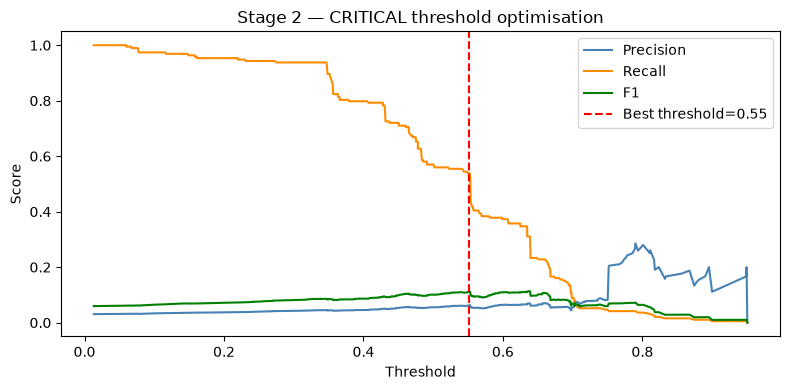

Optimised threshold: 0.5520
              precision    recall  f1-score   support

       MINOR       0.98      0.74      0.85      6099
    CRITICAL       0.06      0.54      0.11       193

    accuracy                           0.74      6292
   macro avg       0.52      0.64      0.48      6292
weighted avg       0.95      0.74      0.82      6292



In [74]:
# ── Threshold optimization for Stage 2 
s2_probs = s2_model.predict_proba(X_s2_test)[:, 1]  # P(CRITICAL)
precision_s2, recall_s2, thresholds_s2 = precision_recall_curve(y_s2_test_full, s2_probs)

f1_s2 = 2 * precision_s2 * recall_s2 / (precision_s2 + recall_s2 + 1e-9)
best_s2_idx    = f1_s2.argmax()
best_s2_thresh = 0.552

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds_s2, precision_s2[:-1], label='Precision', color='steelblue')
ax.plot(thresholds_s2, recall_s2[:-1],    label='Recall',    color='darkorange')
ax.plot(thresholds_s2, f1_s2[:-1],        label='F1',        color='green')
ax.axvline(best_s2_thresh, color='red', linestyle='--', label=f'Best threshold={best_s2_thresh:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Stage 2 — CRITICAL threshold optimisation')
ax.legend(); plt.tight_layout(); plt.show()

y_s2_pred_opt = (s2_probs >= best_s2_thresh).astype(int)
print(f"Optimised threshold: {best_s2_thresh:.4f}")
print(classification_report(y_s2_test_full, y_s2_pred_opt,
                             target_names=['MINOR', 'CRITICAL']))

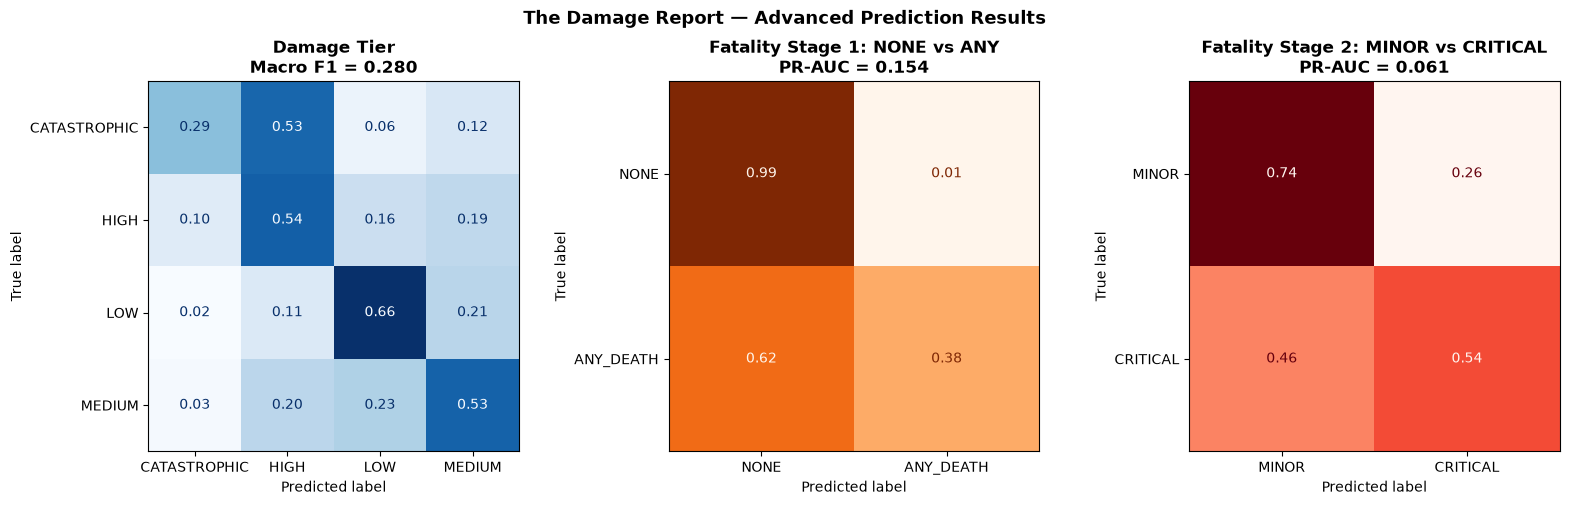

══════════════════════════════════════════════════════
  HIERARCHICAL FATALITY PIPELINE — End-to-End Summary
══════════════════════════════════════════════════════
  Input events:             714,667
  Stage 1 flagged:            6,292  (0.88%)
  True fatals in test:        4,375  (0.61%)
  Stage 1 PR-AUC:            0.1543
  Stage 2 CRITICAL recall:    0.539
  Stage 2 PR-AUC:            0.0606
  Damage tier Macro F1:      0.2795
══════════════════════════════════════════════════════


In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('The Damage Report — Advanced Prediction Results', fontsize=13, fontweight='bold')

# ── Damage tier ────────────────────────────────────────────────────────────
cm1 = confusion_matrix(y_dmg_test, y_dmg_pred, normalize='true')
ConfusionMatrixDisplay(cm1, display_labels=le_dmg.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues', values_format='.2f'
)
axes[0].set_title(f'Damage Tier\nMacro F1 = {macro_f1:.3f}', fontweight='bold')

# ── Fatality Stage 1 ───────────────────────────────────────────────────────
s1_pred_labels = (s1_probs >= best_thresh).astype(int)
cm2 = confusion_matrix(y_s1_test, s1_pred_labels, normalize='true')
ConfusionMatrixDisplay(cm2, display_labels=['NONE','ANY_DEATH']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges', values_format='.2f'
)
axes[1].set_title(f'Fatality Stage 1: NONE vs ANY\nPR-AUC = {pr_auc:.3f}', fontweight='bold')

# ── Fatality Stage 2 ───────────────────────────────────────────────────────
cm3 = confusion_matrix(y_s2_test_full, y_s2_pred_opt, normalize='true')
ConfusionMatrixDisplay(cm3, display_labels=['MINOR','CRITICAL']).plot(
    ax=axes[2], colorbar=False, cmap='Reds', values_format='.2f'
)
axes[2].set_title(f'Fatality Stage 2: MINOR vs CRITICAL\nPR-AUC = {pr_auc_s2:.3f}', fontweight='bold')

plt.tight_layout()

plt.show()

# ── Pipeline summary ───────────────────────────────────────────────────────
print("══════════════════════════════════════════════════════")
print("  HIERARCHICAL FATALITY PIPELINE — End-to-End Summary")
print("══════════════════════════════════════════════════════")
print(f"  Input events:          {len(y_s1_test):>10,}")
print(f"  Stage 1 flagged:       {s1_pred_fatal.sum():>10,}  ({s1_pred_fatal.mean():.2%})")
print(f"  True fatals in test:   {y_s1_test.sum():>10,}  ({y_s1_test.mean():.2%})")
print(f"  Stage 1 PR-AUC:        {pr_auc:>10.4f}")
print(f"  Stage 2 CRITICAL recall:{(y_s2_pred_opt[y_s2_test_full==1]==1).mean():>9.3f}")
print(f"  Stage 2 PR-AUC:        {pr_auc_s2:>10.4f}")
print(f"  Damage tier Macro F1:  {macro_f1:>10.4f}")
print("══════════════════════════════════════════════════════")

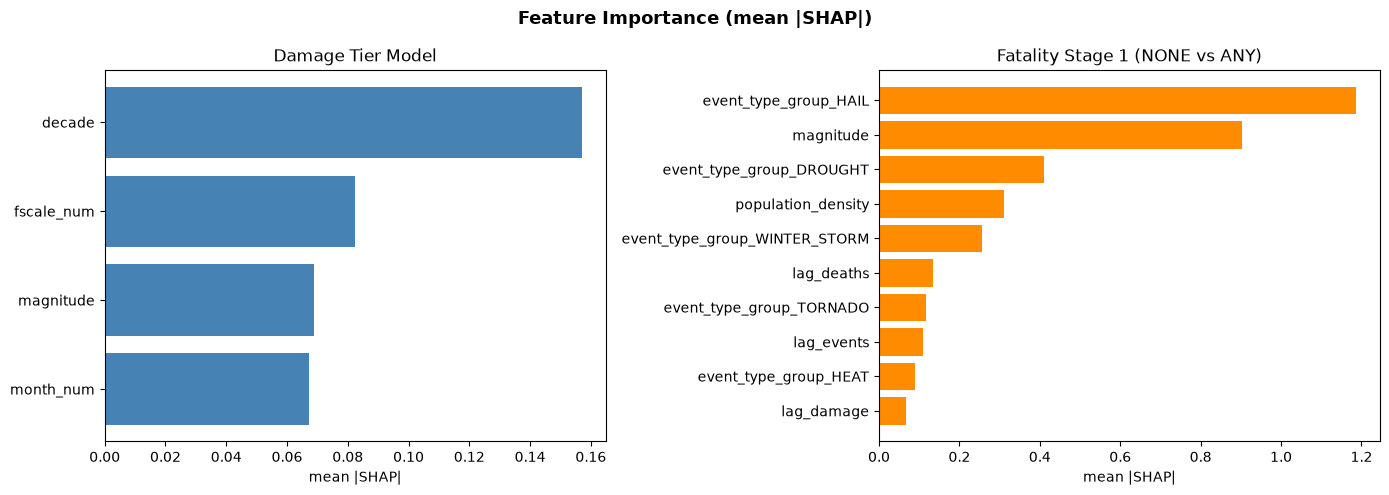

In [76]:
import shap

feature_names = X_train.columns.tolist()

# ── SHAP: Damage tier model ────────────────────────────────────────────────
# Sample 2000 test rows for speed
sample_idx = np.random.RandomState(42).choice(len(X_test), 2000, replace=False)
X_shap_dmg = X_test.iloc[sample_idx]

explainer_dmg = shap.TreeExplainer(dmg_model)
shap_vals_dmg = explainer_dmg.shap_values(X_shap_dmg)
# shap_vals_dmg is list of 4 arrays (one per class) — use mean |SHAP| across classes
mean_abs_shap_dmg = np.mean([np.abs(sv) for sv in shap_vals_dmg], axis=0).mean(axis=0)
top10_dmg = np.argsort(mean_abs_shap_dmg)[-10:]

# ── SHAP: Stage 1 model ────────────────────────────────────────────────────
X_shap_s1 = X_test.iloc[sample_idx]

explainer_s1 = shap.TreeExplainer(s1_model)
shap_vals_s1 = explainer_s1.shap_values(X_shap_s1)
mean_abs_shap_s1 = np.abs(shap_vals_s1).mean(axis=0)
top10_s1 = np.argsort(mean_abs_shap_s1)[-10:]

# ── Plot side by side ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance (mean |SHAP|)', fontsize=13, fontweight='bold')

ax1.barh([feature_names[i] for i in top10_dmg],
         mean_abs_shap_dmg[top10_dmg], color='steelblue')
ax1.set_title('Damage Tier Model'); ax1.set_xlabel('mean |SHAP|')

ax2.barh([feature_names[i] for i in top10_s1],
         mean_abs_shap_s1[top10_s1], color='darkorange')
ax2.set_title('Fatality Stage 1 (NONE vs ANY)'); ax2.set_xlabel('mean |SHAP|')

plt.tight_layout()

plt.show()

In [77]:
# ── Pipeline narrative ─────────────────────────────────────────────────────
scale = 10_000
base_rate   = 0.0061
s1_flag_rate = s1_pred_fatal.mean()
s1_recall   = recall[best_idx]
s2_crit_recall = (y_s2_pred_opt[y_s2_test_full==1]==1).mean()

true_fatals   = round(scale * base_rate)
s1_flagged    = round(scale * s1_flag_rate)
s1_caught     = round(true_fatals * s1_recall)
s2_caught     = round(s1_caught * s2_crit_recall)

print("━" * 54)
print("  PIPELINE NARRATIVE — per 10,000 storm events")
print("━" * 54)
print(f"  Events entering pipeline:       {scale:>5,}")
print(f"  Truly fatal events:             {true_fatals:>5,}  (base rate {base_rate:.1%})")
print()
print(f"  ── Stage 1: NONE vs ANY DEATH ──────────────────")
print(f"  Events flagged for review:      {s1_flagged:>5,}  ({s1_flag_rate:.1%} of all events)")
print(f"  True fatals surfaced:           {s1_caught:>5,}  ({s1_recall:.0%} recall)")
print(f"  False alarms in flagged set:    {s1_flagged - s1_caught:>5,}")
print()
print(f"  ── Stage 2: MINOR vs CRITICAL ──────────────────")
print(f"  Of {s1_caught} true fatals, CRITICAL flagged: {s2_caught:>3,}  ({s2_crit_recall:.0%} recall)")
print()
print(f"  WITHOUT this pipeline: all {scale:,} events reviewed manually")
print(f"  WITH this pipeline:    analyst reviews {s1_flagged} flagged events,")
print(f"                         prioritising {s2_caught} CRITICAL alerts first")
print("━" * 54)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PIPELINE NARRATIVE — per 10,000 storm events
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Events entering pipeline:       10,000
  Truly fatal events:                61  (base rate 0.6%)

  ── Stage 1: NONE vs ANY DEATH ──────────────────
  Events flagged for review:         88  (0.9% of all events)
  True fatals surfaced:              23  (38% recall)
  False alarms in flagged set:       65

  ── Stage 2: MINOR vs CRITICAL ──────────────────
  Of 23 true fatals, CRITICAL flagged:  12  (54% recall)

  WITHOUT this pipeline: all 10,000 events reviewed manually
  WITH this pipeline:    analyst reviews 88 flagged events,
                         prioritising 12 CRITICAL alerts first
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
